In [2]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv()

groq_api_key=os.getenv("GROQ_API_KEY")
# API key direct ga pass cheyyadam
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=groq_api_key
)

response = llm.invoke("What is the capital of Telangana?")
print(response.content)

The capital of Telangana is Hyderabad.


In [30]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict

class LLMState(TypedDict):
    question: str
    answer: str

def llm_node(state:LLMState)->LLMState:
    question=state['question']
    prompt=f"Answer the following question: {question}"
    answer=llm.invoke(prompt).content
    state['answer'] = answer
    return state
def upper_case(state:LLMState)->LLMState:
    state['answer']=state['answer'].upper()
    return state




In [31]:
graph=StateGraph(LLMState)
graph.add_node("LLM_Node", llm_node)
graph.add_node("UpperCase_Node", upper_case)

graph.add_edge(START, "LLM_Node")
graph.add_edge("LLM_Node", "UpperCase_Node")
graph.add_edge("LLM_Node", END)


In [32]:
workflow=graph.compile()

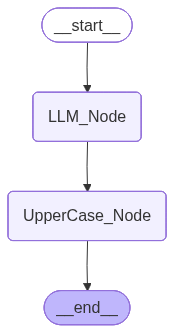

In [33]:
workflow

In [34]:
initial_state={'question': "what is langchain?"}
final_ans=workflow.invoke(initial_state)

In [35]:
print(final_ans['answer'])

LANGCHAIN IS AN OPEN-SOURCE FRAMEWORK DESIGNED TO HELP DEVELOPERS BUILD APPLICATIONS THAT UTILIZE LARGE LANGUAGE MODELS (LLMS) MORE EFFICIENTLY. IT WAS CREATED TO SIMPLIFY THE PROCESS OF INTEGRATING LLMS INTO VARIOUS PROJECTS, PROVIDING A SET OF TOOLS AND LIBRARIES THAT MAKE IT EASIER TO WORK WITH THESE POWERFUL AI MODELS.

LANGCHAIN OFFERS A RANGE OF FEATURES, INCLUDING:

1. **MODULAR ARCHITECTURE**: LANGCHAIN ALLOWS DEVELOPERS TO BREAK DOWN COMPLEX TASKS INTO SMALLER, MORE MANAGEABLE COMPONENTS, MAKING IT EASIER TO BUILD AND MAINTAIN APPLICATIONS THAT LEVERAGE LLMS.
2. **AGENT-BASED ARCHITECTURE**: THE FRAMEWORK INTRODUCES THE CONCEPT OF "AGENTS," WHICH ARE MODULAR COMPONENTS THAT CAN BE COMBINED TO PERFORM SPECIFIC TASKS. THIS APPROACH ENABLES DEVELOPERS TO CREATE COMPLEX WORKFLOWS AND PIPELINES.
3. **MEMORY AND RETRIEVAL MECHANISMS**: LANGCHAIN PROVIDES TOOLS FOR MANAGING MEMORY AND RETRIEVAL MECHANISMS, ALLOWING DEVELOPERS TO STORE AND RETRIEVE INFORMATION GENERATED BY LLMS.
4. **

In [36]:
llm.invoke("what is langchain?").content.upper()

"LANGCHAIN IS AN OPEN-SOURCE FRAMEWORK DESIGNED TO HELP DEVELOPERS BUILD APPLICATIONS THAT UTILIZE LARGE LANGUAGE MODELS (LLMS) MORE EFFICIENTLY. IT WAS CREATED TO SIMPLIFY THE PROCESS OF INTEGRATING LLMS INTO VARIOUS PROJECTS, MAKING IT EASIER FOR DEVELOPERS TO LEVERAGE THE POWER OF THESE MODELS.\n\nLANGCHAIN PROVIDES A SET OF TOOLS AND LIBRARIES THAT ENABLE DEVELOPERS TO:\n\n1. **INTERACT WITH LLMS**: LANGCHAIN OFFERS A UNIFIED INTERFACE TO INTERACT WITH DIFFERENT LLMS, SUCH AS LLAMA, BERT, AND OTHERS, ALLOWING DEVELOPERS TO SWITCH BETWEEN MODELS EASILY.\n2. **MANAGE MEMORY AND COMPUTATION**: LANGCHAIN INCLUDES FEATURES TO OPTIMIZE MEMORY USAGE AND COMPUTATION, MAKING IT POSSIBLE TO RUN LLMS ON DEVICES WITH LIMITED RESOURCES.\n3. **IMPLEMENT CUSTOM LOGIC**: LANGCHAIN ALLOWS DEVELOPERS TO ADD CUSTOM LOGIC AND RULES TO THEIR APPLICATIONS, ENABLING MORE COMPLEX AND NUANCED INTERACTIONS WITH LLMS.\n4. **INTEGRATE WITH OTHER AI MODELS**: LANGCHAIN SUPPORTS INTEGRATION WITH OTHER AI MODELS